# 📊 エリアごとの売上推移

今期の売上をエリア別に分解し、実数と相対比の2つの積み上げ棒グラフで表示する。

> ※ 本notebookはローカルモジュール（`Lv01_03_configuration`）に依存しているため、単体での実行はできません。分析の流れとアウトプットの確認を目的としています。

In [ ]:
# ================================================ #
# imports
# ================================================ #

# 標準ライブラリ
import sys
from pathlib import Path

# 外部ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ローカルモジュール
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path.cwd().parents[1]))
sys.path.insert(0, str(Path.cwd().parents[2]))
from Lv01_03_configuration.cnfg_b_dir_01_local import DIRS
from Lv01_03_configuration.cnfg_d_proc_01_merged import Proc01info, Cols, Items
from Lv01_03_configuration.cnfg_u_local_02_function import generate_dic_ym_to_fiscal_quarter
from Lv01_03_configuration.cnfg_p_chart import generate_chart_region_sales_stacked
from Lv01_03_configuration.cnfg_a_api_01_pub import (
    pmod_01_loading_df as func_loading_df,
    pmod_20_formatting_datetime as func_datetime_format,
)

In [14]:
# ================================================ #
# データ読み込み・加工
# ================================================ #

# データ読み込み
df = func_loading_df.read_as_dataframe_from_excel_or_csv(
    target_file_path=Path(DIRS.Processed) / Proc01info.FILENAME
)

# 年月カラムの追加
df = (
    df.copy()
    .pipe(
        func_datetime_format.format_ss_half_y4m2,
        target_col        = Cols.order_date,
        output_col        = Cols.order_ym,
        trans_to_datetime = True
    )
)

# 集計期間の設定
fiscal_start_month = 1
start_year         = 2025
start_month        = 1
end_year           = start_year
end_month          = 12

# 今期の年月リスト生成
dic_current_quarter = generate_dic_ym_to_fiscal_quarter(
    fiscal_start_month = fiscal_start_month,
    start_year         = start_year,
    start_month        = start_month,
    end_year           = end_year,
    end_month          = end_month
)
current_list_full = list(dic_current_quarter)
current_list      = current_list_full[:7]

# 今期データ抽出
current_df = (
    df.loc[df[Cols.order_ym].isin(current_list)]
    .copy()
    .reset_index(drop=True)
)

# エリア別・月別に集計
x_axis_col       = Cols.order_ym
x_axis_item_list = current_list_full
y_axis_col       = Cols.region
y_axis_item_list = Items.list_region
color_map        = Items.light_color_map_region()

current_df = (
    current_df.copy()
    .groupby([x_axis_col, y_axis_col], as_index=False)[Cols.sales]
    .sum()
)
current_df[Cols.sales] = current_df[Cols.sales].round(1)

# 全月・全エリアの枠を作成してマージ
current_full = pd.MultiIndex.from_product(
    [x_axis_item_list, y_axis_item_list],
    names=[x_axis_col, y_axis_col]
).to_frame(index=False)

current_df = current_full.merge(
    right=current_df,
    on=[x_axis_col, y_axis_col],
    how='left',
).fillna(0)

# ピボット集計
df_pivot = current_df.pivot_table(
    index      = x_axis_col,
    columns    = y_axis_col,
    values     = Cols.sales,
    aggfunc    = "sum",
    fill_value = 0
)

# 相対比の計算
df_pivot_ratio = df_pivot.div(df_pivot.sum(axis=1), axis=0).mul(100).round(1)


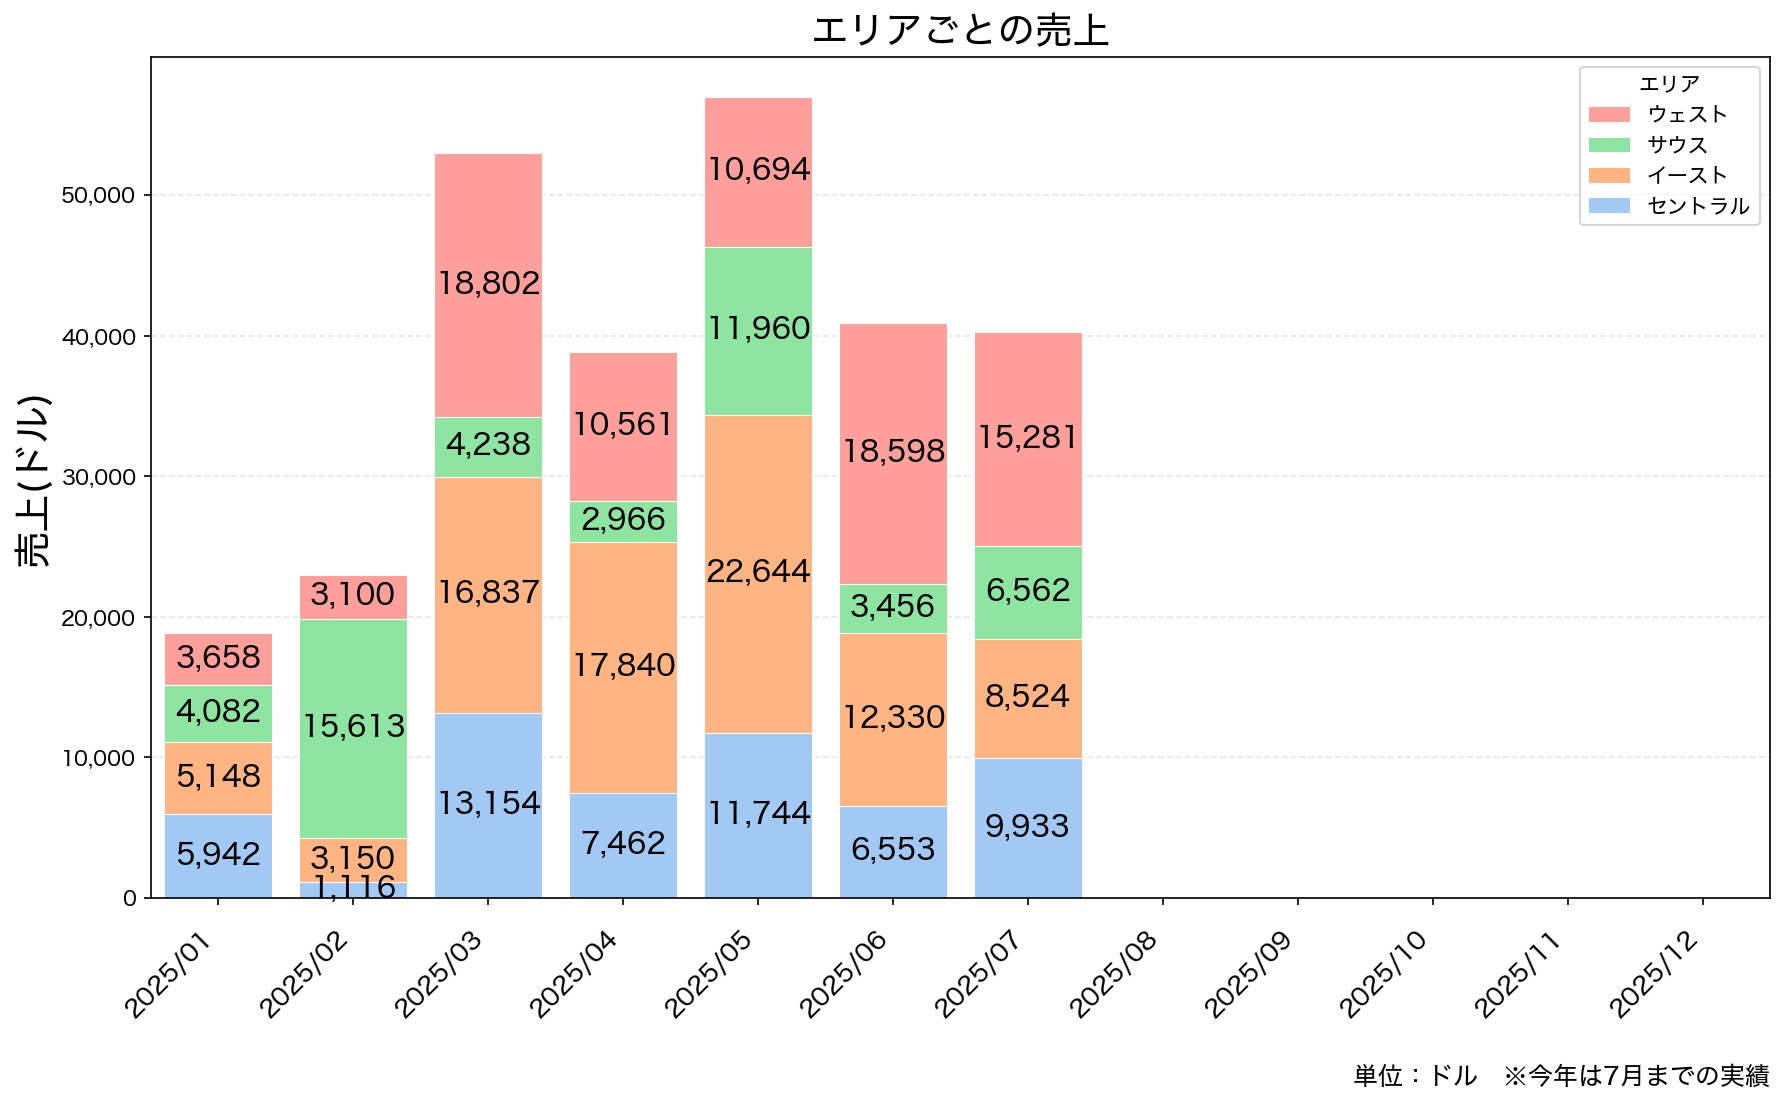

In [15]:
# ================================================ #
# チャート生成①：実数
# ================================================ #

plt.rcParams['font.family'] = 'Hiragino Sans'
fig, ax = plt.subplots(figsize=(12, 7.5), dpi=150)

generate_chart_region_sales_stacked(
    df_pivot         = df_pivot,
    ax               = ax,
    x_axis_item_list = x_axis_item_list,
    y_axis_item_list = y_axis_item_list,
    color_map        = color_map,
    title            = "エリアごとの売上",
    ylabel           = "売上(ドル)",
    note             = "単位：ドル　※今年は7月までの実績",
    is_ratio         = False,
)

plt.tight_layout()
plt.show()

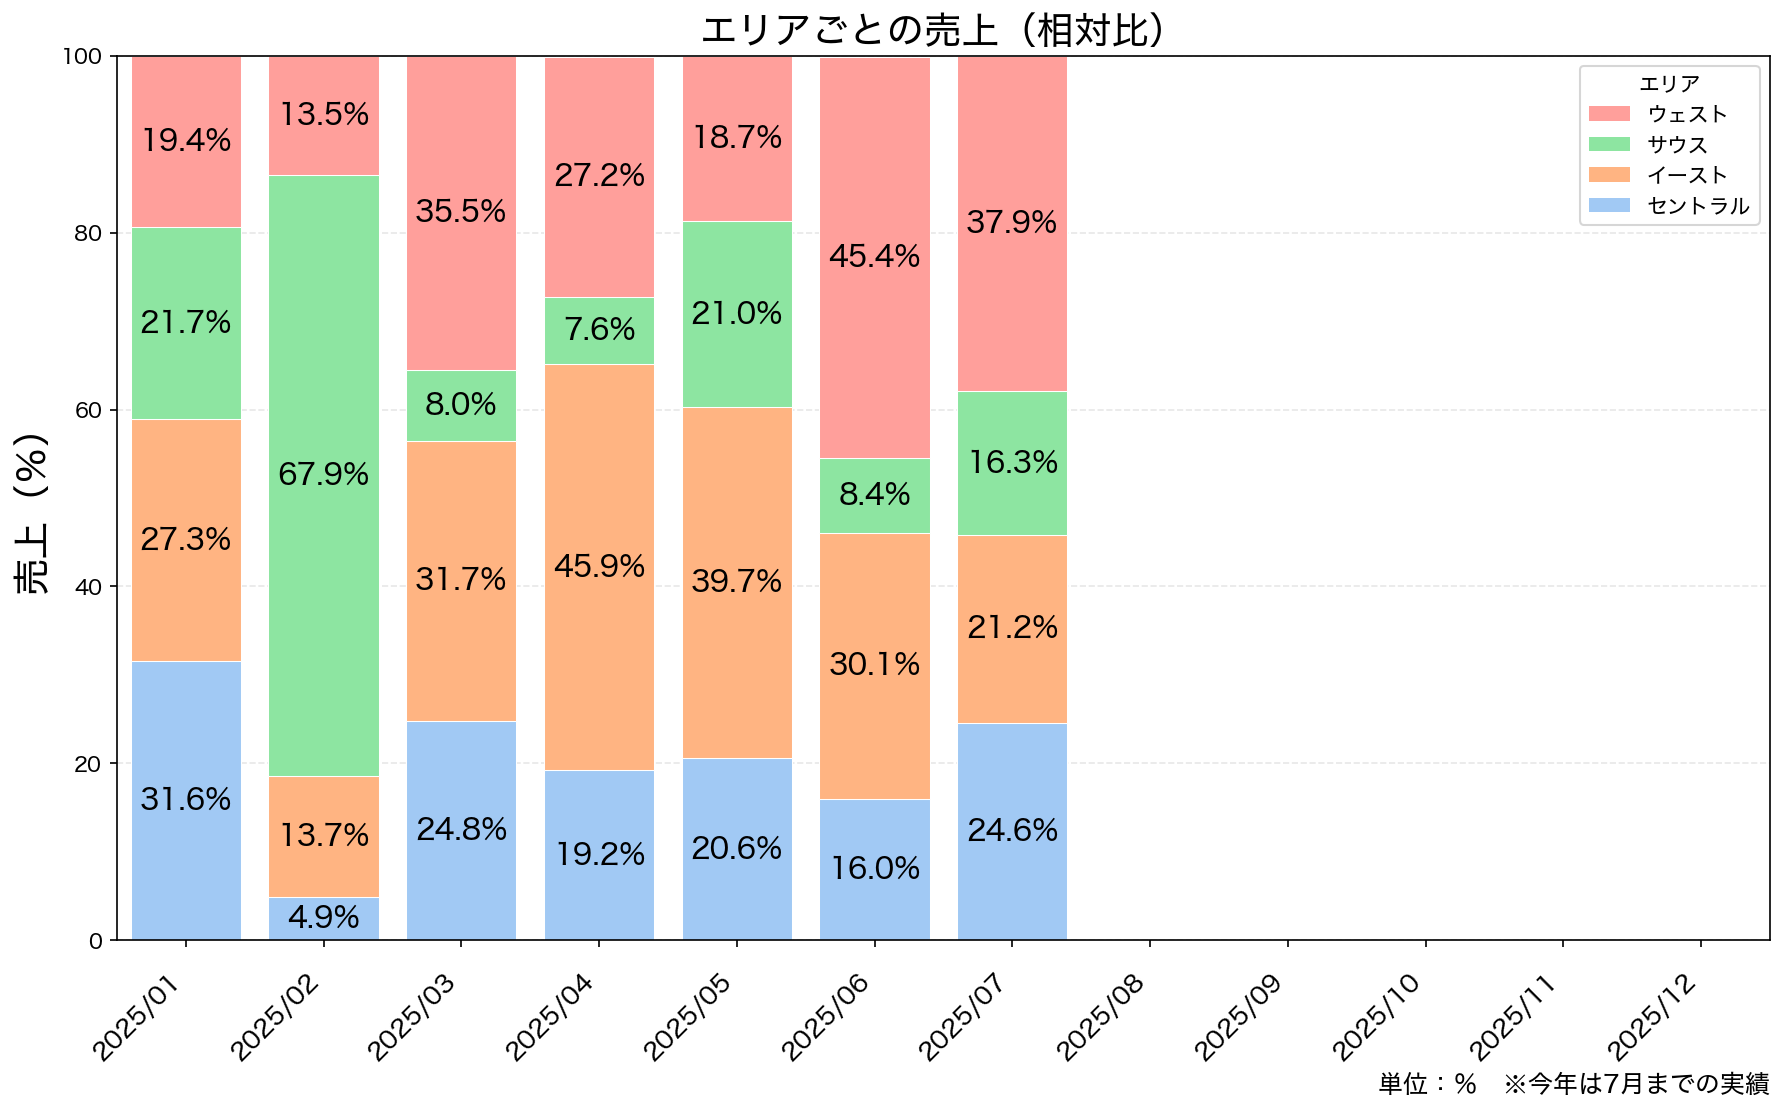

In [16]:
# ================================================ #
# チャート生成②：相対比
# ================================================ #

plt.rcParams['font.family'] = 'Hiragino Sans'
fig, ax = plt.subplots(figsize=(12, 7.5), dpi=150)

generate_chart_region_sales_stacked(
    df_pivot         = df_pivot_ratio,
    ax               = ax,
    x_axis_item_list = x_axis_item_list,
    y_axis_item_list = y_axis_item_list,
    color_map        = color_map,
    title            = "エリアごとの売上（相対比）",
    ylabel           = "売上（％）",
    note             = "単位：％　※今年は7月までの実績",
    is_ratio         = True,
)

plt.tight_layout()
plt.show()